<a href="https://colab.research.google.com/github/TamirPalay/DI_Exercises/blob/main/week10/day5-6/CNN_Daily.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPool2D
from tensorflow.keras.utils import to_categorical

In [2]:
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
X_train shape: (60000, 28, 28)
y_train shape: (60000,)
X_test shape: (10000, 28, 28)
y_test shape: (10000,)


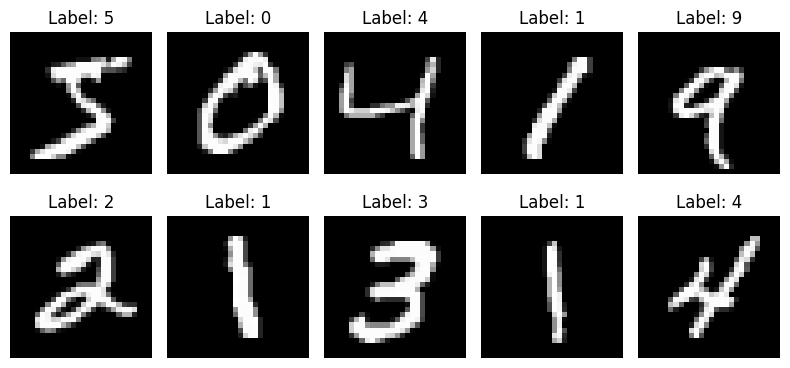

In [3]:
plt.figure(figsize=(8, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")
plt.tight_layout()
plt.show()

In [4]:
# Flatten 28x28 -> 784
X_train_flat = X_train.reshape(X_train.shape[0], 28 * 28)
X_test_flat = X_test.reshape(X_test.shape[0], 28 * 28)

# Normalize
X_train_flat = X_train_flat.astype("float32") / 255.0
X_test_flat = X_test_flat.astype("float32") / 255.0

# One-hot encode labels
y_train_cat = to_categorical(y_train, num_classes=10)
y_test_cat = to_categorical(y_test, num_classes=10)

print("X_train_flat shape:", X_train_flat.shape)
print("y_train_cat shape:", y_train_cat.shape)

X_train_flat shape: (60000, 784)
y_train_cat shape: (60000, 10)


In [5]:
fc_model = Sequential([
    Dense(128, activation="relu", input_shape=(784,)),
    Dense(64, activation="relu"),
    Dense(10, activation="softmax")
])

fc_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

fc_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
fc_history = fc_model.fit(
    X_train_flat, y_train_cat,
    validation_split=0.1,
    epochs=10,
    batch_size=128,
    verbose=1
)

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8986 - loss: 0.3575 - val_accuracy: 0.9615 - val_loss: 0.1429
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9572 - loss: 0.1453 - val_accuracy: 0.9693 - val_loss: 0.1090
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9701 - loss: 0.0990 - val_accuracy: 0.9727 - val_loss: 0.0950
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9774 - loss: 0.0751 - val_accuracy: 0.9747 - val_loss: 0.0794
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9824 - loss: 0.0586 - val_accuracy: 0.9750 - val_loss: 0.0798
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9856 - loss: 0.0467 - val_accuracy: 0.9768 - val_loss: 0.0762
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9876 - loss: 0.0394 - val_accuracy: 0.9757 - val_loss: 0.0896
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9911 - loss: 0.0307 - val_accuracy: 0.

In [7]:
fc_loss, fc_acc = fc_model.evaluate(X_test_flat, y_test_cat, verbose=0)
print(f"Fully Connected NN — Test Loss: {fc_loss:.4f}, Test Accuracy: {fc_acc:.4f}")

Fully Connected NN — Test Loss: 0.0858, Test Accuracy: 0.9766


In [8]:
# Reshape to (samples, 28, 28, 1) for Conv2D
X_train_cnn = X_train.reshape(X_train.shape[0], 28, 28, 1).astype("float32") / 255.0
X_test_cnn = X_test.reshape(X_test.shape[0], 28, 28, 1).astype("float32") / 255.0

# Labels already one-hot encoded from Cell 4 (y_train_cat, y_test_cat) — reuse them

print("X_train_cnn shape:", X_train_cnn.shape)
print("X_test_cnn shape:", X_test_cnn.shape)

X_train_cnn shape: (60000, 28, 28, 1)
X_test_cnn shape: (10000, 28, 28, 1)


In [9]:
cnn_model = Sequential([
    Conv2D(32, kernel_size=(3, 3), activation="relu", input_shape=(28, 28, 1)),
    MaxPool2D(pool_size=(2, 2)),

    Conv2D(64, kernel_size=(3, 3), activation="relu"),
    MaxPool2D(pool_size=(2, 2)),

    Flatten(),
    Dense(128, activation="relu"),
    Dense(10, activation="softmax")
])

cnn_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
cnn_history = cnn_model.fit(
    X_train_cnn, y_train_cat,
    validation_split=0.1,
    epochs=10,
    batch_size=128,
    verbose=1
)

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 38s 86ms/step - accuracy: 0.9333 - loss: 0.2273 - val_accuracy: 0.9807 - val_loss: 0.0687
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 37s 87ms/step - accuracy: 0.9823 - loss: 0.0583 - val_accuracy: 0.9867 - val_loss: 0.0447
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 36s 86ms/step - accuracy: 0.9880 - loss: 0.0393 - val_accuracy: 0.9860 - val_loss: 0.0414
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 87ms/step - accuracy: 0.9902 - loss: 0.0309 - val_accuracy: 0.9882 - val_loss: 0.0424
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 36s 86ms/step - accuracy: 0.9922 - loss: 0.0236 - val_accuracy: 0.9887 - val_loss: 0.0362
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 37s 87ms/step - accuracy: 0.9944 - loss: 0.0185 - val_accuracy: 0.9907 - val_loss: 0.0324
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 87ms/step - accuracy: 0.9948 - loss: 0.0152 - val_accuracy: 0.9880 - val_loss: 0.0419
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 36s 86ms/step - accuracy: 0.9961 - loss: 0.0129 - 

In [11]:
cnn_loss, cnn_acc = cnn_model.evaluate(X_test_cnn, y_test_cat, verbose=0)
print(f"CNN — Test Loss: {cnn_loss:.4f}, Test Accuracy: {cnn_acc:.4f}")

CNN — Test Loss: 0.0375, Test Accuracy: 0.9899


Model                    Test Accuracy  Test Loss 
Fully Connected NN       0.9766         0.0858    
CNN                      0.9899         0.0375    


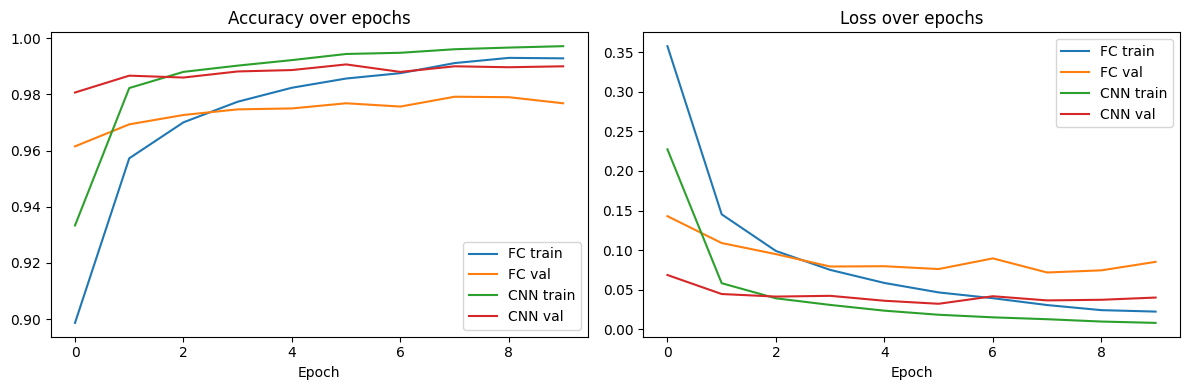

In [12]:
print(f"{'Model':<25}{'Test Accuracy':<15}{'Test Loss':<10}")
print(f"{'Fully Connected NN':<25}{fc_acc:<15.4f}{fc_loss:<10.4f}")
print(f"{'CNN':<25}{cnn_acc:<15.4f}{cnn_loss:<10.4f}")

# Plot training curves side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(fc_history.history["accuracy"], label="FC train")
axes[0].plot(fc_history.history["val_accuracy"], label="FC val")
axes[0].plot(cnn_history.history["accuracy"], label="CNN train")
axes[0].plot(cnn_history.history["val_accuracy"], label="CNN val")
axes[0].set_title("Accuracy over epochs")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(fc_history.history["loss"], label="FC train")
axes[1].plot(fc_history.history["val_loss"], label="FC val")
axes[1].plot(cnn_history.history["loss"], label="CNN train")
axes[1].plot(cnn_history.history["val_loss"], label="CNN val")
axes[1].set_title("Loss over epochs")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()